# Gnatcatcher Project


### Project Overview

The coastal California Gnatcatcher is a tiny gray bird that is listed as federally threatened and is also designated as a Bird Species of Special Concern by the State of California. These birds live in or near coastal sage shrub, are highly territorial, and are non-migratory. They play a vital role in the ecosystem of coastal Southern California by keeping the population of pests in check. 

This project analyzes how coastal sage scrub habitat has changed across Southern California from 2001 to 2021, whether fragmentation has increased, and what the spatial distribution of gnatcatcher observations reveals about gnatcatcher vulnerability and resilience. 

### Data Loading and Cleaning

In [173]:
import os
import ee
import geopandas as gpd
import rasterio
import geemap
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from rasterio.mask import mask as rio_mask
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from rasterio.transform import rowcol
from scipy import ndimage
np.random.seed(42)

In [174]:
gbif = pd.read_csv('data/raw/GBIF.csv', sep='\t', low_memory=False)
print(gbif['year'].min(), gbif['year'].max())
print(gbif['scientificName'].value_counts())
print(gbif['basisOfRecord'].value_counts())

1860.0 2026.0
scientificName
Polioptila californica Brewster, 1881                54855
Polioptila californica californica Brewster, 1881      376
Polioptila melanura californica Brewster, 1881         196
Name: count, dtype: int64
basisOfRecord
HUMAN_OBSERVATION     54893
PRESERVED_SPECIMEN      467
OBSERVATION              63
OCCURRENCE                4
Name: count, dtype: int64


In [175]:
cols = ['scientificName', 'decimalLatitude', 'decimalLongitude', 
        'year', 'month', 'day', 'coordinateUncertaintyInMeters',
        'basisOfRecord', 'locality']

gbif_clean = gbif[cols].dropna(subset=['decimalLatitude', 'decimalLongitude', 'year'])

In [176]:
gnatcatcher = gpd.GeoDataFrame(
    gbif_clean,
    geometry=gpd.points_from_xy(gbif_clean['decimalLongitude'], gbif_clean['decimalLatitude']),
    crs='EPSG:4326'
)

In [177]:
gnatcatcher.to_file('data/processed/gnatcatcher_clean.gpkg', driver='GPKG')

In [178]:
ee.Initialize(project='gnatcatcher-project')

In [179]:
socal = ee.Geometry.Rectangle([-120.5, 32.5, -116.5, 34.6])

nlcd_2001 = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2001').select('landcover').clip(socal)
nlcd_2021 = ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021').select('landcover').clip(socal)

In [180]:
# Export 2001
task1 = ee.batch.Export.image.toDrive(
    image=nlcd_2001,
    description='NLCD_2001_SoCal',
    folder='gnatcatcher',
    fileNamePrefix='nlcd_2001_socal',
    scale=30,
    region=socal,
    crs='EPSG:4326',
    maxPixels=1e9
)
task1.start()

# Export 2021
task2 = ee.batch.Export.image.toDrive(
    image=nlcd_2021,
    description='NLCD_2021_SoCal',
    folder='gnatcatcher',
    fileNamePrefix='nlcd_2021_socal',
    scale=30,
    region=socal,
    crs='EPSG:4326',
    maxPixels=1e9
)
task2.start()

             NAME STATEFP
47         Orange      06
50        Ventura      06
326   Los Angeles      06
1269    San Diego      06


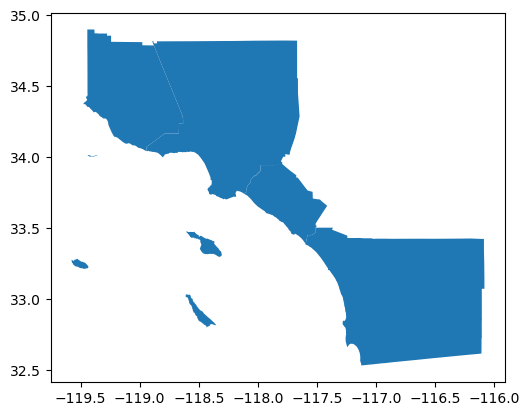

In [181]:
# Load all US counties
counties_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
counties = gpd.read_file(counties_url)

# Filter to our four coastal counties in California
# California FIPS code is 06
coastal_counties = counties[
    (counties['STATEFP'] == '06') & 
    (counties['NAME'].isin(['San Diego', 'Orange', 'Los Angeles', 'Ventura']))
]

print(coastal_counties[['NAME', 'STATEFP']])
coastal_counties.plot()
plt.show()

In [182]:
coastal_counties = coastal_counties.to_crs('EPSG:4326')

In [183]:
geometries = coastal_counties['geometry'].values
with rasterio.open('data/raw/nlcd_2001_socal.tif') as src:
    clipped_2001, transform_2001 = rio_mask(src, geometries, crop=True)
    profile = src.profile
with rasterio.open('data/raw/nlcd_2021_socal.tif') as src:
    clipped_2021, transform_2021 = rio_mask(src, geometries, crop=True)

In [184]:
profile.update(
    height=clipped_2001.shape[1],
    width=clipped_2001.shape[2],
    transform=transform_2001
)

with rasterio.open('data/processed/nlcd_2001_coastal.tif', 'w', **profile) as dst:
    dst.write(clipped_2001)

with rasterio.open('data/processed/nlcd_2021_coastal.tif', 'w', **profile) as dst:
    dst.write(clipped_2021)

### Land Cover Change Analysis

The plot below shows the spatial distribution of gnatcatchers in Southern California. Observations are clustered in San Diego and Orange County, consistent with known coastal sage scrub distribution.  

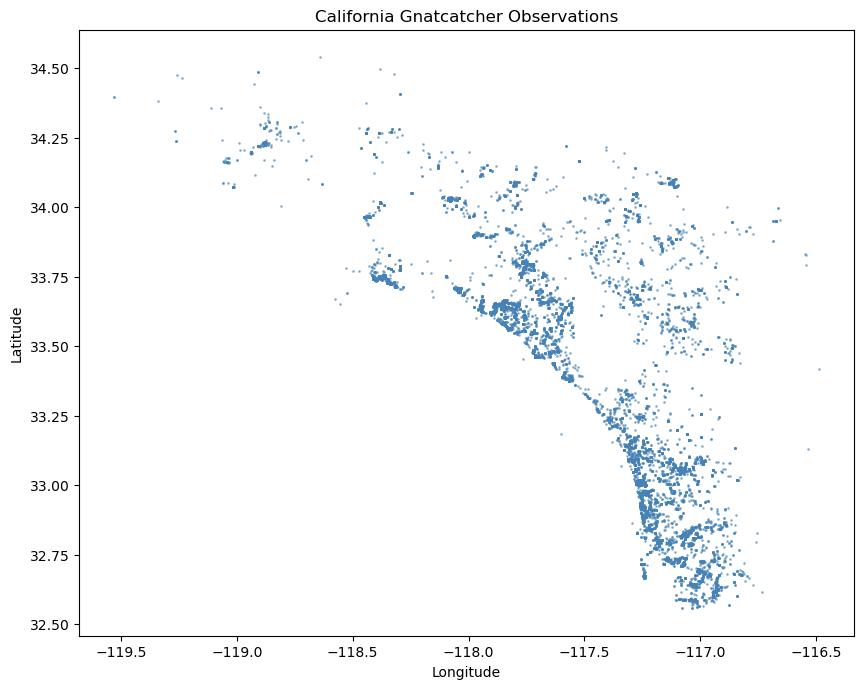

In [185]:
fig, ax = plt.subplots(figsize=(10, 8))
gnatcatcher.plot(ax=ax, markersize=1, color='steelblue', alpha=0.5)
ax.set_title('California Gnatcatcher Observations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

The analysis below reveals that shrub has increased by 0.3%. At face value, this might indicate that gnatcatcher habitat (coastal sage scrub) is relatively stable. However, this masks substantial churn: 179,506 hectares of shrub have been lost, and 183,522 hectares have been gained, suggesting that there is a lot of large-scale habitat turnover likely driven by wildfires. One limitation of this project is that there is no publicly available coastal sage scrub land cover code. The land cover code '52' is for general shrub/scrub and while it includes coastal sage scrub, it is not limited to it. It is entirely possible that coastal sage scrub has decreased while other shrub types have increased, keeping the net change artificially stable.

In [186]:
shrub_2001 = np.sum(clipped_2001[0] == 52)
shrub_2021 = np.sum(clipped_2021[0] == 52)

pixel_area_hectares = 0.09  # 30m x 30m pixel = 900 sq meters = 0.09 hectares

area_2001 = shrub_2001 * pixel_area_hectares
area_2021 = shrub_2021 * pixel_area_hectares
change = area_2021 - area_2001
pct_change = (change / area_2001) * 100

print(f"Shrub/scrub 2001: {area_2001:,.0f} hectares")
print(f"Shrub/scrub 2021: {area_2021:,.0f} hectares")
print(f"Change: {change:,.0f} hectares")
print(f"Percent change: {pct_change:.1f}%")

Shrub/scrub 2001: 1,161,062 hectares
Shrub/scrub 2021: 1,165,079 hectares
Change: 4,017 hectares
Percent change: 0.3%


In [187]:
loss = (clipped_2001[0] == 52) & (clipped_2021[0] != 52)
gain = (clipped_2001[0] != 52) & (clipped_2021[0] == 52)

In [188]:
change_raster = np.zeros_like(clipped_2001[0])
change_raster[loss] = 1  # loss = 1
change_raster[gain] = 2  # gain = 2

print(f"Loss pixels: {np.sum(loss):,}")
print(f"Gain pixels: {np.sum(gain):,}")
print(f"Loss area: {np.sum(loss) * 0.09:,.0f} hectares")
print(f"Gain area: {np.sum(gain) * 0.09:,.0f} hectares")

Loss pixels: 1,994,508
Gain pixels: 2,039,138
Loss area: 179,506 hectares
Gain area: 183,522 hectares


In [189]:
gnatcatcher_precise = gnatcatcher[
    (gnatcatcher['coordinateUncertaintyInMeters'] < 1000) |
    (gnatcatcher['coordinateUncertaintyInMeters'].isna())
].copy()

print(f"Original: {len(gnatcatcher):,} points")
print(f"Precise only: {len(gnatcatcher_precise):,} points")

Original: 55,424 points
Precise only: 54,999 points


In [190]:
# Sample landcover_2001 onto gnatcatcher_precise
lons = gnatcatcher_precise['decimalLongitude'].values
lats = gnatcatcher_precise['decimalLatitude'].values

rows, cols_idx = rowcol(transform_2001, lons, lats)
rows = np.array(rows)
cols_idx = np.array(cols_idx)

raster_height, raster_width = clipped_2001[0].shape
valid = (rows >= 0) & (rows < raster_height) & (cols_idx >= 0) & (cols_idx < raster_width)

lc_2001 = np.zeros(len(rows), dtype=int)
lc_2001[valid] = clipped_2001[0][rows[valid], cols_idx[valid]]
gnatcatcher_precise['landcover_2001'] = lc_2001

# Sample landcover_2021 onto gnatcatcher_precise
rows, cols_idx = rowcol(transform_2021, lons, lats)
rows = np.array(rows)
cols_idx = np.array(cols_idx)

raster_height, raster_width = clipped_2021[0].shape
valid = (rows >= 0) & (rows < raster_height) & (cols_idx >= 0) & (cols_idx < raster_width)

lc_2021 = np.zeros(len(rows), dtype=int)
lc_2021[valid] = clipped_2021[0][rows[valid], cols_idx[valid]]
gnatcatcher_precise['landcover_2021'] = lc_2021

print(gnatcatcher_precise[['landcover_2001', 'landcover_2021']].head())

    landcover_2001  landcover_2021
5               52              52
6               23              23
7               52              52
8               23              23
10               0               0


I overlaid the spatial gnatcatcher observations on a map of shrub change from 2001-2021. I found that most gnatcatcher observations clustered in areas showing shrub gain (green) which is an increase in shrub/scrub habitat from 2001-2021. At face value, this might look like a good thing. However, this indicates that gnatcatchers are heavily reliant on habitat that is fluctuating. The most plausible reason for this “gain” in habitat is post-fire recovery: the Viejas Fire in 2001, the Cedar Fire in 2003, and the Witch Fire in 2007 burnt down large areas of shrub and the 2021 land cover captures two decades' worth of regrowth. This means that post-fire shrub regrowth creates a false sense of habitat stability when the underlying trend is probably still negative. Additionally, ongoing urban development continues to transform suitable gnatcatcher habitat to concrete, and unlike wildfires, this change is permanent.   

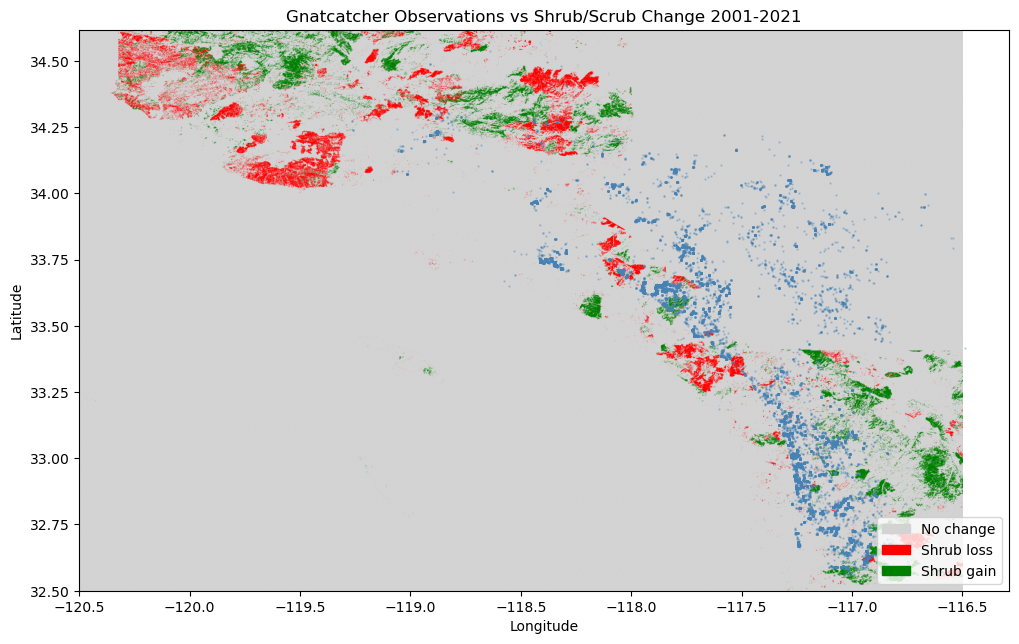

In [191]:
extent = [-120.50019187484945, -116.4998142516084, 32.499969001103345, 34.61657947354576]
cmap = ListedColormap(['lightgrey', 'red', 'green'])

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(change_raster, cmap=cmap, extent=extent, origin='upper')
gnatcatcher.plot(ax=ax, markersize=0.5, color='steelblue', alpha=0.3)
ax.set_title('Gnatcatcher Observations vs Shrub/Scrub Change 2001-2021')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

patches = [
    mpatches.Patch(color='lightgrey', label='No change'),
    mpatches.Patch(color='red', label='Shrub loss'),
    mpatches.Patch(color='green', label='Shrub gain'),
]
ax.legend(handles=patches, loc='lower right')
plt.show()

### Temporal Analysis

In [192]:
gnatcatcher_human = gnatcatcher_precise[gnatcatcher_precise['basisOfRecord'] == 'HUMAN_OBSERVATION']

In [193]:
pre_2010 = gnatcatcher_human[gnatcatcher_human['year'] < 2010]
post_2015 = gnatcatcher_human[gnatcatcher_human['year'] >= 2015]

print(f"Pre-2010: {len(pre_2010):,} observations")
print(f"Post-2015: {len(post_2015):,} observations")

pre_2010_rate = (pre_2010['landcover_2021'] == 52).mean() * 100
post_2015_rate = (post_2015['landcover_2021'] == 52).mean() * 100

print(f"Pre-2010 on shrub/scrub (2021 raster): {pre_2010_rate:.1f}%")
print(f"Post-2015 on shrub/scrub (2021 raster): {post_2015_rate:.1f}%")

Pre-2010: 4,014 observations
Post-2015: 45,481 observations
Pre-2010 on shrub/scrub (2021 raster): 17.3%
Post-2015 on shrub/scrub (2021 raster): 21.3%


In [194]:
def bootstrap_median(data, var = "landcover_2021"):
    bs_sample = post_2015.sample(4014, replace = True)
    return np.mean((bs_sample[var] == 52) * 100)

In [195]:
bs_means = np.array([])
num_bootstraps = 1000

for i in np.arange(num_bootstraps):
    bs_means = np.append(bs_means, bootstrap_median(post_2015, var = 'landcover_2021'))


In [196]:
print(f"Mean: {bs_means.mean():.2f}%")
print(f"2.5th percentile: {np.percentile(bs_means, 2.5):.2f}%")
print(f"97.5th percentile: {np.percentile(bs_means, 97.5):.2f}%")
print(f"Pre-2010 actual value: {pre_2010_rate:.1f}%")

Mean: 21.30%
2.5th percentile: 20.10%
97.5th percentile: 22.60%
Pre-2010 actual value: 17.3%


The analysis above reveals that there are 45,481 gnatcatcher observations post-2015 and 4,014 observations pre-2010. This imbalance can be attributed to iNaturalist's merger with the California Academy of Sciences in 2014 which increased the popularity of the app. Because of this sample size disparity, we cannot fairly compare the results. To assess whether this difference was meaningful, I bootstrapped the post-2015 sample 1000 times. The 95% confidence interval was 20.10% to 22.60%. Since the pre-2010 value of 17.3% falls outside this range, the difference is statistically significant. We can conclude that pre-2010, gnatcatchers were less likely to be found on scrub (17.3%) than post-2015 (21.3%). This likely reflects observer bias rather than a true habitat shift. Prior to 2010, iNaturalist was mainly used by casual naturalists, while the post-2015 research-grade framework of the app attracted more serious researchers actively surveying scrub habitat. 

### Fragmentation Analysis

When parts of a species’ habitat are damaged by human activity or occupied by agriculture, pieces of what once was one large natural area become isolated patches. This is the process of habitat fragmentation and it leads to reduced genetic diversity and species resilience, and disrupts food chains. Gnatcatchers are known to be highly territorial and need roughly 1-4 hectares of continuous land for one territory.

To assess whether fragmentation has increased across coastal Southern California, I analyzed shrub patch counts and sizes from the 2001 and 2021 NLCD rasters. The number of distinct shrub patches in 2001 was 114,330, and the number of distinct shrub patches in 2021 was 135,585. That represents an 18.6% increase in the number of patches. Median patch size remained 0.18 hectares for both years. This is well below the 1-4 hectares range needed to support a pair of breeding gnatcatchers. 

In [197]:
shrub_2001_mask = clipped_2001[0] == 52
shrub_2021_mask = clipped_2021[0] == 52

In [198]:
labeled_2001, num_patches_2001 = ndimage.label(shrub_2001_mask)
print(f"Number of distinct shrub patches in 2001: {num_patches_2001:,}")
labeled_2021, num_patches_2021 = ndimage.label(shrub_2021_mask)
print(f"Number of distinct shrub patches in 2021: {num_patches_2021:,}")

Number of distinct shrub patches in 2001: 114,330
Number of distinct shrub patches in 2021: 135,585


In [199]:
patch_sizes_2001 = ndimage.sum(shrub_2001_mask, labeled_2001, range(1, num_patches_2001 + 1))
patch_sizes_2001 = np.array(patch_sizes_2001) * 0.09  # convert to hectares
patch_sizes_2021 = ndimage.sum(shrub_2021_mask, labeled_2021, range(1, num_patches_2021 + 1))
patch_sizes_2021 = np.array(patch_sizes_2021) * 0.09  # convert to hectares


print(f"Median patch size 2001: {np.median(patch_sizes_2001):.2f} hectares")
print(f"Mean patch size 2001: {np.mean(patch_sizes_2001):.2f} hectares")
print(f"Largest patch 2001: {np.max(patch_sizes_2001):,.0f} hectares")
print(f"Patches under 1 hectare 2001: {np.sum(patch_sizes_2001 < 1):,}")

print(f"Median patch size 2021: {np.median(patch_sizes_2021):.2f} hectares")
print(f"Mean patch size 2021: {np.mean(patch_sizes_2021):.2f} hectares")
print(f"Largest patch 2021: {np.max(patch_sizes_2021):,.0f} hectares")
print(f"Patches under 1 hectare 2021: {np.sum(patch_sizes_2021 < 1):,}")

Median patch size 2001: 0.18 hectares
Mean patch size 2001: 10.16 hectares
Largest patch 2001: 25,222 hectares
Patches under 1 hectare 2001: 94,267
Median patch size 2021: 0.18 hectares
Mean patch size 2021: 8.59 hectares
Largest patch 2021: 39,090 hectares
Patches under 1 hectare 2021: 114,378


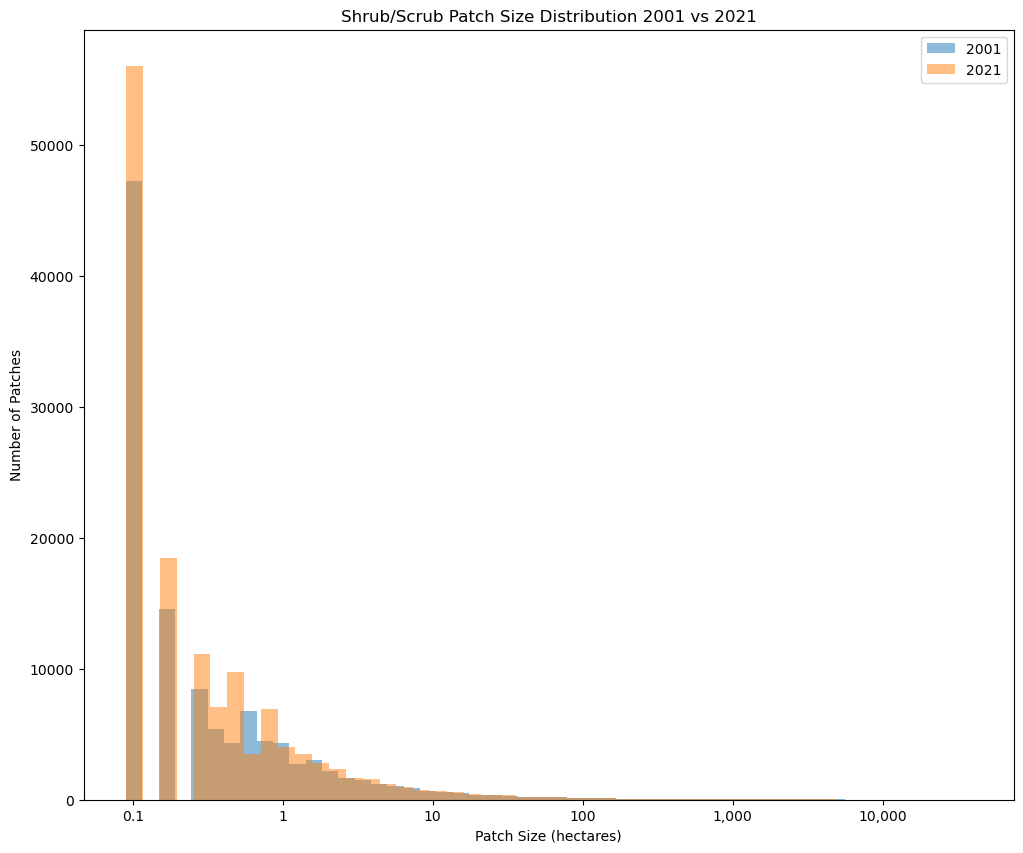

In [200]:
fig, ax = plt.subplots(figsize=(12, 10))

plt.hist(np.log10(patch_sizes_2001), alpha=0.5, bins=50, label='2001')
plt.hist(np.log10(patch_sizes_2021), alpha=0.5, bins=50, label='2021')

plt.xlabel('Patch Size (hectares)')
plt.ylabel('Number of Patches')
plt.title('Shrub/Scrub Patch Size Distribution 2001 vs 2021')

tick_locations = [-1, 0, 1, 2, 3, 4]
tick_labels = ['0.1', '1', '10', '100', '1,000', '10,000']
plt.xticks(tick_locations, tick_labels)

plt.legend()
plt.show()

The 2021 distribution (orange) dominates the smallest patch bins, with sub-1 hectare fragments increasing from 94,000 to 114,000 between 2001 and 2021. This tells us that fragmentation is worsening, and that new shrub growth is appearing as tiny isolated patches rather than expanding existing large ones.

### Conclusion

The Coastal California gnatcatcher is an indicator species for the Southern California ecosystem and acts as a natural pest controller, keeping insect populations in check. It is listed as federally threatened due to its heavy dependence on coastal sage scrub which is declining due to urbanization. 

The overarching problem is habitat instability and fragmentation. From 2001-2021, 179,506 hectares of shrub have been lost, and 183,522 hectares have been gained, suggesting large-scale habitat turnover likely driven by wildfires. Overlaying spatial gnatcatcher observations on a map of shrub change from 2001-2021 reveals gnatcatcher observations clustered in areas showing shrub gain (green). This indicates that gnatcatchers are heavily reliant on fragile habitat that is at the mercy of wildfires. Temporal analysis suggests that the increase in scrub observations over time reflects observer bias from iNaturalist's growth rather than genuine habitat recovery. Analysis of the NLCD rasters in 2001 and 2021 also revealed that habitat fragmentation has increased, and the median size of each patch is 0.18 hectares, when the size required by a pair of breeding birds is between 1-4 hectares.